<a href="https://colab.research.google.com/github/sumanth4005/AI-Customer-Review-Intelligence/blob/main/review_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
from google.colab import files
uploaded = files.upload()

Saving googleplaystore.csv.zip to googleplaystore.csv (1).zip


In [12]:
import pandas as pd
!unzip -o "googleplaystore.csv (1).zip"
!ls
import pandas as pd
df = pd.read_csv("googleplaystore.csv")
df.head()
reviews = pd.read_csv("googleplaystore.csv")
reviews.head()

Archive:  googleplaystore.csv (1).zip
  inflating: googleplaystore.csv     
 googleplaystore.csv	        googleplaystore.csv.zip
'googleplaystore.csv (1).zip'   sample_data


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [13]:
import pandas as pd
df = pd.read_csv("googleplaystore.csv")
print(df.shape)
df.info()

(10841, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [14]:
df = df.drop_duplicates(subset="App")
df = df[df["Category"] != "1.9"]   # removes one known broken row in this dataset

df["Reviews"]  = pd.to_numeric(df["Reviews"], errors="coerce")
df["Installs"] = pd.to_numeric(df["Installs"].str.replace("[+,]", "", regex=True), errors="coerce")
df["Price"]    = pd.to_numeric(df["Price"].str.replace("$", "", regex=False), errors="coerce")

print(df.shape)
df.isnull().sum()

(9659, 13)


,0
App,0
Category,0
Rating,1463
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,0
Genres,0


In [15]:
cat = (df.groupby("Category")
         .agg(apps=("App", "count"),
              avg_rating=("Rating", "mean"),
              total_installs=("Installs", "sum"))
         .sort_values("avg_rating"))
cat.round(2)

,apps,avg_rating,total_installs
Category,,,
DATING,171,3.97,140926107
MAPS_AND_NAVIGATION,131,4.04,503281890
TOOLS,827,4.04,8001771915
VIDEO_PLAYERS,163,4.04,3926902720
TRAVEL_AND_LOCAL,219,4.07,2894887146
LIFESTYLE,369,4.09,503823539
BUSINESS,420,4.10,697164865
FINANCE,345,4.12,455348734
COMMUNICATION,315,4.12,11038276251


In [16]:
df.groupby("Type")["Rating"].agg(["count", "mean"]).round(2)

,count,mean
Type,,
Free,7592,4.17
Paid,604,4.26


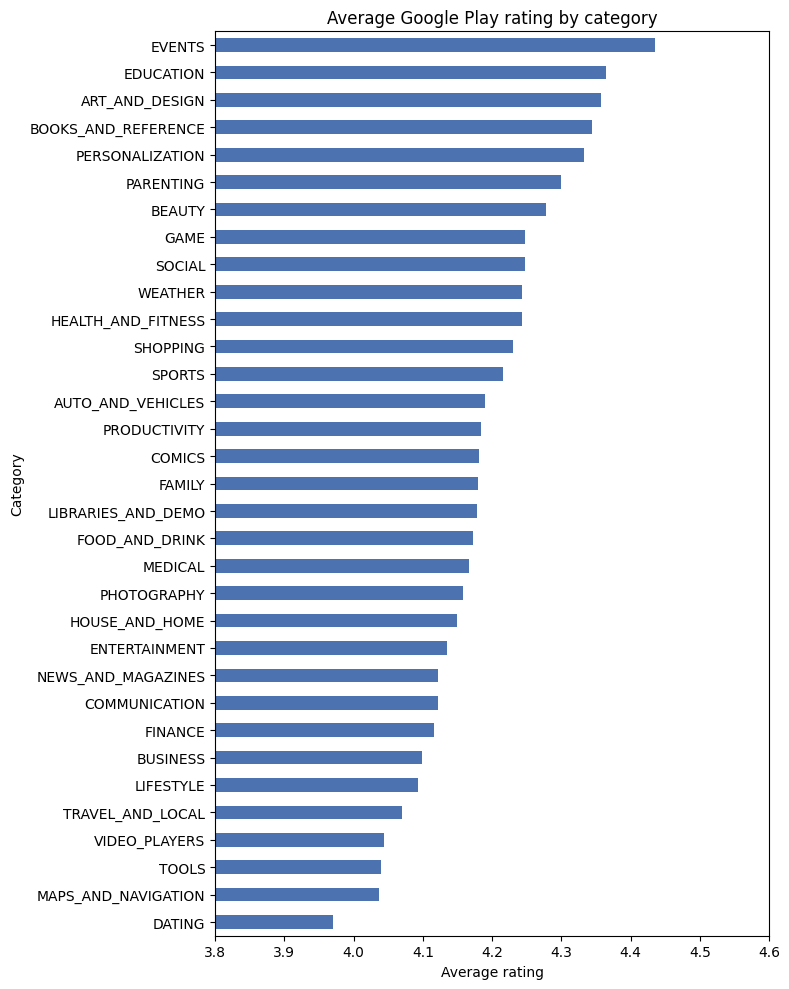

In [21]:
import matplotlib.pyplot as plt

cat.head(5).round(2)
cat["avg_rating"].sort_values().plot(kind="barh", figsize=(8, 10), color="#4C72B0")
plt.xlabel("Average rating")
plt.title("Average Google Play rating by category")
plt.xlim(3.8, 4.6)
plt.tight_layout()
plt.show()

In [26]:
reviews = pd.read_csv("googleplaystore_user_reviews.csv").dropna(subset=["Translated_Review"])
print(reviews.shape)
reviews["Sentiment"].value_counts(normalize=True).round(3)

FileNotFoundError: [Errno 2] No such file or directory: 'googleplaystore_user_reviews.csv'

In [38]:
!ls
from google.colab import files
uploaded = files.upload()

 googleplaystore.csv		   'googleplaystore.csv (1).zip'
'googleplaystore.csv (1) (1).zip'  'googleplaystore.csv (2).zip'
'googleplaystore.csv (1) (2).zip'   googleplaystore.csv.zip
'googleplaystore.csv (1) (3).zip'   sample_data


Saving googleplaystore.csv (1).zip to googleplaystore.csv (1) (4).zip


In [39]:
!unzip -o "googleplaystore_user_reviews*.zip"
!ls

unzip:  cannot find or open googleplaystore_user_reviews*.zip, googleplaystore_user_reviews*.zip.zip or googleplaystore_user_reviews*.zip.ZIP.

No zipfiles found.
 googleplaystore.csv		   'googleplaystore.csv (1).zip'
'googleplaystore.csv (1) (1).zip'  'googleplaystore.csv (2).zip'
'googleplaystore.csv (1) (2).zip'   googleplaystore.csv.zip
'googleplaystore.csv (1) (3).zip'   sample_data
'googleplaystore.csv (1) (4).zip'


In [48]:
apps = pd.read_csv(os.path.join(path, "googleplaystore.csv")).drop_duplicates(subset="App")
data = reviews.merge(apps[["App", "Category", "Rating"]], on="App", how="left")
print(data.shape)
data[["App", "Category", "Sentiment", "Translated_Review"]].head()
neg = (data.groupby("Category")
         .agg(reviews=("Sentiment", "count"),
              negative_share=("Sentiment", lambda s: (s == "Negative").mean()))
         .query("reviews >= 300")
         .sort_values("negative_share", ascending=False))
neg.round(3).head(10)
app_neg = (data.groupby("App")
             .agg(reviews=("Sentiment", "count"),
                  negative_share=("Sentiment", lambda s: (s == "Negative").mean()))
             .query("reviews >= 50")
             .sort_values("negative_share", ascending=False))
app_neg.round(3).head(10)

(37427, 7)


,reviews,negative_share
App,,
Candy Crush Jelly Saga,73,0.603
Be A Legend: Soccer,98,0.602
Cooking Fever,135,0.585
Candy Crush Soda Saga,166,0.578
Angry Birds Classic,273,0.538
Candy Crush Saga,240,0.525
Agar.io,136,0.485
8 Ball Pool,219,0.484
Homescapes,52,0.481


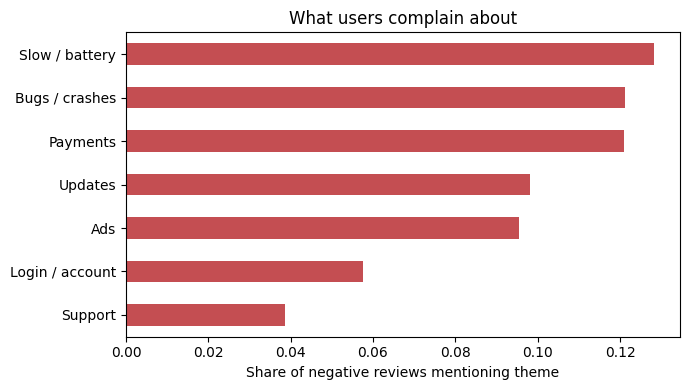

In [50]:
themes = {
    "Ads":            r"\bads?\b|advert",
    "Bugs / crashes": r"crash|bug|freez|not work|doesn.?t work|error|glitch",
    "Updates":        r"update",
    "Payments":       r"pay|money|refund|subscri|charg|price",
    "Login / account":r"login|log in|sign in|account|password",
    "Slow / battery": r"slow|lag|battery|load",
    "Support":        r"support|customer service|respond|reply",
}
negatives = data[data["Sentiment"] == "Negative"]["Translated_Review"].str.lower()
theme_counts = pd.Series({t: negatives.str.contains(p, regex=True).mean() for t, p in themes.items()})
theme_counts.sort_values(ascending=False).round(3)
theme_counts.sort_values().plot(kind="barh", figsize=(7, 4), color="#C44E52")
plt.xlabel("Share of negative reviews mentioning theme")
plt.title("What users complain about")
plt.tight_layout()
plt.show()

In [53]:
   neg.round(3).head(10)

,reviews,negative_share
Category,,
GAME,6678,0.361
SOCIAL,741,0.282
FAMILY,2009,0.275
NEWS_AND_MAGAZINES,1040,0.265
ENTERTAINMENT,1264,0.252
VIDEO_PLAYERS,331,0.251
SPORTS,1479,0.228
FINANCE,1435,0.223
TRAVEL_AND_LOCAL,1692,0.217


In [54]:
   themes["Slow / battery"] = r"slow|\blag|battery|\bloading\b|takes forever"
   theme_counts = pd.Series({t: negatives.str.contains(p, regex=True).mean() for t, p in themes.items()})
   theme_counts.sort_values(ascending=False).round(3)

,0
Bugs / crashes,0.121
Payments,0.121
Updates,0.098
Ads,0.095
Slow / battery,0.074
Login / account,0.058
Support,0.039
